# Cancer Type Prediction from Gene Expression Data

**Objective:** Build a machine learning model that can predict the type of cancer
(BRCA, KIRC, LUAD, PRAD, COAD) using gene expression data from the TCGA Pan-Cancer dataset.

The dataset contains 801 patient samples with 20,531 gene expression values each.

In [1]:
# Step 1: Import all required libraries

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

# create folders to save outputs
os.makedirs('models', exist_ok=True)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

We have two CSV files:
- `data.csv` — gene expression values for each patient
- `labels.csv` — the cancer type label for each patient

In [2]:
# load gene expression data and labels
data = pd.read_csv('data/raw/data.csv').rename(columns={'Unnamed: 0': 'sample_id'})
labels = pd.read_csv('data/raw/labels.csv').rename(columns={'Unnamed: 0': 'sample_id'})

# merge both files on sample_id
df = data.merge(labels, on='sample_id')

print(f"Total samples: {df.shape[0]}")
print(f"Total genes: {df.shape[1] - 2}")  # minus sample_id and Class columns
print(f"Cancer types: {df['Class'].unique()}")
print()
print("First 3 rows:")
df.head(3)

Total samples: 801
Total genes: 20531
Cancer types: ['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']

First 3 rows:


,sample_id,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD


## Step 3: Explore the Data

Let's see how many samples we have for each cancer type.

Samples per cancer type:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


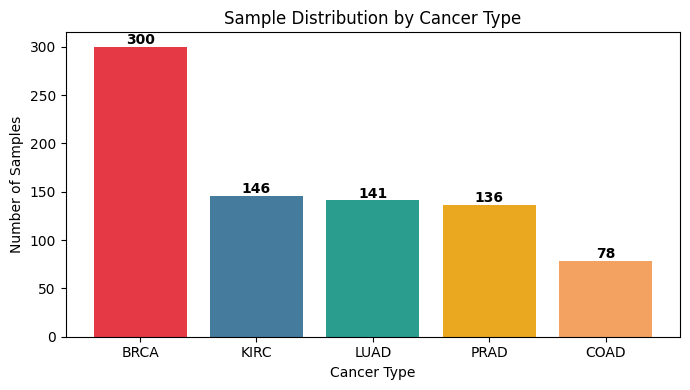

In [3]:
# count samples per cancer type
class_counts = df['Class'].value_counts()
print("Samples per cancer type:")
print(class_counts)

# plot bar chart
colors = {'BRCA':'#E63946', 'KIRC':'#457B9D', 'LUAD':'#2A9D8F', 'PRAD':'#E9A820', 'COAD':'#F4A261'}

plt.figure(figsize=(7, 4))
bars = plt.bar(class_counts.index, class_counts.values,
               color=[colors[c] for c in class_counts.index])

# add count labels on each bar
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontweight='bold')

plt.xlabel('Cancer Type')
plt.ylabel('Number of Samples')
plt.title('Sample Distribution by Cancer Type')
plt.tight_layout()
plt.show()

In [4]:
# separate features (X) and target (y)
X = df.drop(columns=['sample_id', 'Class'])
y = df['Class']

# check for missing values
print(f"Any missing values? {X.isnull().values.any()}")
print(f"Shape of X: {X.shape}")
print(f"Gene expression range: {X.values.min():.2f} to {X.values.max():.2f}")

Any missing values? False
Shape of X: (801, 20531)
Gene expression range: 0.00 to 20.78


## Step 4: Split Data into Training and Testing Sets

We use 80% data for training and 20% for testing. Stratified split ensures
each cancer type is equally represented in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 640
Testing samples:  161


## Step 5: Dimensionality Reduction using PCA

We have 20,531 genes which is too many features. PCA helps us reduce
this to a smaller number while keeping most of the important information.

We first check how many components are needed to keep 95% of the variance.

Components needed for 95% variance: 1


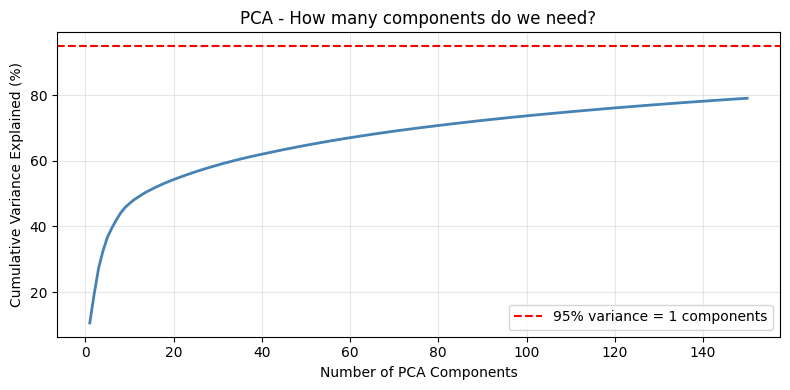


We will use 100 PCA components


In [6]:
# standardize the data first (PCA needs scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# fit PCA with 150 components to check variance
pca_check = PCA(n_components=150, random_state=42)
pca_check.fit(X_train_scaled)

# cumulative variance explained
cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_) * 100

# find how many components needed for 95% variance
n_for_95 = np.argmax(cumulative_variance >= 95) + 1
print(f"Components needed for 95% variance: {n_for_95}")

# plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, 151), cumulative_variance, color='steelblue', linewidth=2)
plt.axhline(y=95, color='red', linestyle='--', label=f'95% variance = {n_for_95} components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('PCA - How many components do we need?')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# we'll use 100 components (covers >95% variance)
N_COMPONENTS = 100
print(f"\nWe will use {N_COMPONENTS} PCA components")

## Step 6: Train and Compare Three Models

We build three different classifiers using a Pipeline:
**StandardScaler → PCA → Classifier**

Models:
1. Logistic Regression
2. Random Forest
3. SVM (Support Vector Machine)

In [7]:
# define three pipelines (each does: scale -> PCA -> classify)
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=N_COMPONENTS, random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=N_COMPONENTS, random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=N_COMPONENTS, random_state=42)),
        ('clf', SVC(kernel='rbf', C=10, probability=True, random_state=42))
    ]),
}

# train each model and evaluate using 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Training models...\n")
for name, pipe in pipelines.items():
    # cross validation on training data
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    
    # train on full training set and test
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc
    }
    
    print(f"{name:25s}  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})  Test Accuracy: {test_acc:.4f}")

# show results as a table
print()
pd.DataFrame(results).T

Training models...

Logistic Regression        CV Accuracy: 0.9984 (+/- 0.0031)  Test Accuracy: 0.9876
Random Forest              CV Accuracy: 0.9812 (+/- 0.0080)  Test Accuracy: 0.9752
SVM                        CV Accuracy: 0.9938 (+/- 0.0058)  Test Accuracy: 0.9814



,cv_mean,cv_std,test_acc
Logistic Regression,0.998437,0.003125,0.987578
Random Forest,0.981250,0.007967,0.975155
SVM,0.993750,0.005846,0.981366


## Step 7: Evaluate the Best Model

We pick the model with the highest test accuracy and look at its
detailed performance using a classification report and confusion matrix.

In [8]:
# find the best model
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = pipelines[best_name]

print(f"Best Model: {best_name}")
print(f"Test Accuracy: {results[best_name]['test_acc']:.4f}")
print()

# get predictions
y_pred = best_model.predict(X_test)
cancer_types = sorted(y.unique())

# classification report
print("Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=cancer_types))

Best Model: Logistic Regression
Test Accuracy: 0.9876

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.96      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.98      0.98       161
weighted avg       0.99      0.99      0.99       161



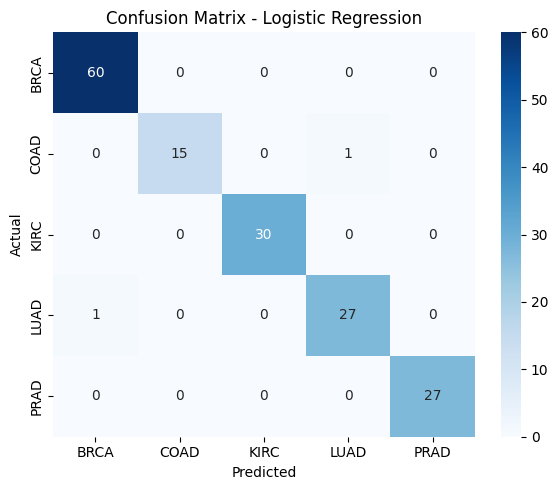

In [9]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=cancer_types)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer_types, yticklabels=cancer_types)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

## Step 8: Visualize the Data using PCA (2D)

We reduce all 20,531 genes to just 2 dimensions using PCA so we can
see how different cancer types cluster together.

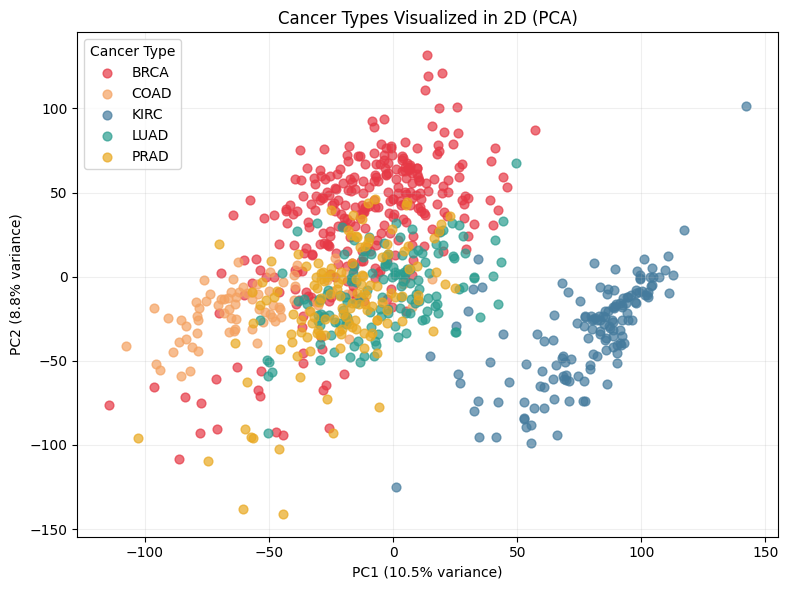

In [10]:
# apply PCA with 2 components for visualization
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(StandardScaler().fit_transform(X))

# create a dataframe for plotting
plot_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1], 'Cancer': y.values})

plt.figure(figsize=(8, 6))
for cancer in cancer_types:
    subset = plot_df[plot_df['Cancer'] == cancer]
    plt.scatter(subset['PC1'], subset['PC2'], label=cancer,
                color=colors[cancer], alpha=0.7, s=40)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Cancer Types Visualized in 2D (PCA)')
plt.legend(title='Cancer Type')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Step 9: Save the Trained Model

We save the best model and feature names so we can use them
in our web application later.

In [11]:
# save the best model
joblib.dump(best_model, 'models/best_model.pkl')

# save feature names (gene names) - needed for the web app
pd.Series(X.columns.tolist()).to_csv('models/feature_names.csv', index=False, header=False)

# save cancer class labels
pd.Series(sorted(y.unique())).to_csv('models/cancer_classes.csv', index=False, header=False)

print("Model saved successfully!")
print(f"  Model: {best_name}")
print(f"  Accuracy: {results[best_name]['test_acc']:.4f}")
print(f"  Files saved in 'models/' folder")

Model saved successfully!
  Model: Logistic Regression
  Accuracy: 0.9876
  Files saved in 'models/' folder


## Summary

- **Dataset:** 801 samples, 20,531 genes, 5 cancer types
- **Preprocessing:** StandardScaler + PCA (reduced to 100 components)
- **Models tested:** Logistic Regression, Random Forest, SVM
- **Best model and accuracy:** See output above
- **Next step:** Run the web app using `streamlit run app.py`

> *Note: This model is for educational purposes only, not for clinical use.*